# Nipah Virus — Named Entity Recognition (NER)

---

| | |
|---|---|
| **Mata Kuliah** | COMP6885001 — Natural Language Processing |
| **Topik** | Information Extraction menggunakan spaCy Rule-Based NER |
| **Entitas** | `DISEASE`, `SYMPTOM`, `LOCATION` |
| **Dataset** | Web scraping berita + dataset manual (300 kalimat) |
| **Model** | spaCy EntityRuler (rule-based, CPU-friendly) |

---

## Latar Belakang

Virus Nipah (NiV) adalah virus zoonosis berbahaya yang pertama kali ditemukan di Malaysia tahun 1998. Penyakit ini dapat menyebabkan ensefalitis (radang otak) hingga kematian dengan tingkat fatalitas mencapai 40–75%.

Proyek ini membangun sistem **Named Entity Recognition (NER)** untuk mengekstrak informasi penting dari teks berita dan artikel tentang virus Nipah secara otomatis:
- 🔴 **DISEASE** — nama penyakit/virus (contoh: *virus Nipah, ensefalitis, NiV*)
- 🟡 **SYMPTOM** — gejala klinis (contoh: *demam, kejang, sesak napas*)
- 🔵 **LOCATION** — lokasi kejadian (contoh: *Malaysia, Kerala, Bangladesh*)

---

## Alur Pipeline

```
1. Install & Import
2. Web Scraping Berita  ──┐
3. Load Dataset Lama   ──┴──▶  4. Gabung & Deduplikasi
                                        │
                                        ▼
                               5. Preprocessing
                                        │
                                        ▼
                           6. NER spaCy Rule-Based
                                        │
                                        ▼
                           7. Evaluasi (P / R / F1)
                                        │
                                        ▼
                          8. Simpan Model & Dataset
```

---
## 1. Install & Import

Library yang digunakan:

| Library | Fungsi |
|---|---|
| `spacy` | NLP pipeline & EntityRuler untuk rule-based NER |
| `en_core_web_sm` | Model bahasa Inggris kecil dari spaCy |
| `requests` + `beautifulsoup4` | Web scraping artikel berita |
| `pandas` | Manipulasi dan penyimpanan dataset |
| `re` | Preprocessing teks dengan regex |

In [ ]:
!pip install -q spacy requests beautifulsoup4 lxml
!python -m spacy download en_core_web_sm -q
!pip install -q datasets
!pip install -q wikipedia-api
print('Semua library berhasil diinstall!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 43.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.3 MB/s eta 0:00:00
Semua library berhasil diinstall!


In [ ]:
import os
import pandas as pd
import requests
import re
import time
import spacy
import wikipediaapi
import unicodedata

from collections import Counter
from datasets import load_dataset
from spacy.pipeline import EntityRuler
from bs4 import BeautifulSoup
from collections import defaultdict
from spacy import displacy


print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## 2. Web Scraping Berita

Untuk memperbanyak data, dilakukan **web scraping** otomatis dari Google News RSS Feed.

### Mengapa Web Scraping?
Dataset yang dikumpulkan secara manual memiliki keterbatasan jumlah dan variasi kalimat. Web scraping memungkinkan kita mendapatkan data yang lebih banyak, lebih beragam, dan mencerminkan penggunaan bahasa yang nyata (*real-world text*).

### Sumber Data
- **Google News RSS** — snippet judul dan deskripsi berita dari berbagai media
- Query menggunakan kata kunci **Bahasa Indonesia dan Inggris** untuk cakupan yang lebih luas

> **Catatan etika:** Data hanya mengambil snippet publik dari RSS feed (bukan full article) sehingga tidak melanggar *terms of service*.

In [ ]:
def scrape_google_news(query, max_articles=20):
    """
    Scraping snippet berita dari Google News RSS Feed.
    - Tidak memerlukan API key
    - Gratis dan legal (mengakses feed publik)
    """
    query_encoded = query.replace(' ', '+')
    url = f'https://news.google.com/rss/search?q={query_encoded}&hl=id&gl=ID&ceid=ID:id'
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.content, 'xml')
        items = soup.find_all('item')
    except Exception as e:
        print(f'Gagal scraping "{query}": {e}')
        return []

    results = []
    for item in items[:max_articles]:
        title = item.find('title').text if item.find('title') else ''
        desc  = item.find('description').text if item.find('description') else ''
        raw   = title + '. ' + desc
        clean = BeautifulSoup(raw, 'html.parser').get_text()
        clean = re.sub(r'\s+', ' ', clean).strip()
        if len(clean) > 30:
            results.append(clean)
    return results

In [ ]:
# Daftar query — kombinasi Bahasa Indonesia & Inggris
queries = [
    'virus nipah',
    'nipah virus outbreak',
    'virus nipah gejala',
    'nipah virus symptoms',
    'wabah nipah malaysia india',
    'nipah encephalitis',
    'virus nipah penularan kelelawar',
]

scraped_texts = []
for q in queries:
    texts = scrape_google_news(q, max_articles=20)
    scraped_texts.extend(texts)
    print(f'  ✔ Query "{q}" → {len(texts)} artikel')
    time.sleep(1)  # jeda agar tidak diblokir server

print(f'\nTotal teks terkumpul dari scraping: {len(scraped_texts)}')

  ✔ Query "virus nipah" → 20 artikel
  ✔ Query "nipah virus outbreak" → 20 artikel
  ✔ Query "virus nipah gejala" → 20 artikel
  ✔ Query "nipah virus symptoms" → 20 artikel
  ✔ Query "wabah nipah malaysia india" → 20 artikel
  ✔ Query "nipah encephalitis" → 20 artikel
  ✔ Query "virus nipah penularan kelelawar" → 20 artikel

📰 Total teks terkumpul dari scraping: 140


In [ ]:
def split_sentences(texts):
    """
    Memecah teks panjang menjadi kalimat-kalimat individual.
    Kalimat kurang dari 20 karakter dibuang (biasanya noise).
    """
    sentences = []
    for text in texts:
        parts = re.split(r'(?<=[.!?])\s+', text)
        for part in parts:
            part = part.strip()
            if len(part) > 20:
                sentences.append(part)
    return sentences

scraped_sentences = split_sentences(scraped_texts)
print(f'Total kalimat dari scraping: {len(scraped_sentences)}')
print('\nContoh kalimat hasil scraping:')
for s in scraped_sentences[:3]:
    print(f'  - {s}')

🔢 Total kalimat dari scraping: 300

Contoh kalimat hasil scraping:
  - Pemkot Surabaya Terbitkan SE Kewaspadaan Virus Nipah, Warga Diminta Perketat PHBS - Pemerintah Kota Surabaya.
  - Pemkot Surabaya Terbitkan SE Kewaspadaan Virus Nipah, Warga Diminta Perketat PHBS Pemerintah Kota Surabaya
  - Apa Itu Virus Nipah yang Berpotensi Jadi Ancaman Kesehatan Global?


---
## 3. Load Dataset yang Lama (Manual)

Dataset ini berisi **300 kalimat** yang dikumpulkan secara manual dari berbagai artikel dan berita tentang virus Nipah. Dataset ini akan digabungkan dengan hasil scraping untuk membentuk dataset yang lebih lengkap.

>  `Dataset Nipah.csv`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive berhasil terhubung!')

Mounted at /content/drive
Google Drive berhasil terhubung!


In [ ]:
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'nipah' in file.lower() or 'Nipah' in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/model_A_nipah_NER.ipynb
/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/nipah_ner_model.zip
/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/Dataset Nipah.csv
/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/Dataset_Nipah_Final.gsheet
/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/Dataset_Nipah_Final.csv
/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Requirements Docs/Named Entity Recognition for Disease and Symptom Extraction in Nipah Virus Text using Rule-Based and NLP Methods.gdoc


In [ ]:
PATH_DATASET= '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/Dataset Nipah.csv'

In [ ]:
# Sesuaikan path ini dengan lokasi file di Google Drive kamu
data = []
with open(PATH_DATASET, 'r', encoding='utf-8', errors='replace') as f:
    f.readline()  # skip baris header
    for line in f:
        line = line.strip()
        if line:
            parts = line.split(',', 1)
            if len(parts) == 2:
                data.append(parts[1])

df_lama = pd.DataFrame({'text': data})
print(f'Dataset sebelumnya berhasil diload: {len(df_lama)} kalimat')
df_lama.head(5)

Dataset sebelumnya berhasil diload: 300 kalimat


,text
0,Virus nipah (NiV) adalah virus zoonosis yang b...
1,Pertama kali diidentifikasi pada tahun 1998 di...
2,Menurut data dari World Health Organization (W...
3,"People with infection can develop a fever, and..."
4,Fruit bats of the Pteropodidae family are the ...


---
## Load Dataset Kaggle — Disease Symptom Description

Dataset ini didownload dari **Kaggle** (`itachi9604/disease-symptom-description-dataset`) dan disimpan di Google Drive.

File yang digunakan: `symptom_Description.csv` — berisi nama penyakit dan deskripsi gejala dalam bentuk kalimat.

> Path: `.../Dataset/Kaggle/symptom_Description.csv`

In [ ]:
PATH_KAGGLE = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/Kaggle/symptom_Description.csv'

df_kaggle = pd.read_csv(PATH_KAGGLE)
print(f'Kolom tersedia: {df_kaggle.columns.tolist()}')
print(f'Total baris   : {len(df_kaggle)}')
df_kaggle.head(5)

Kolom tersedia: ['Disease', 'Description']
Total baris   : 41


,Disease,Description
0,Drug Reaction,An adverse drug reaction (ADR) is an injury ca...
1,Malaria,An infectious disease caused by protozoan para...
2,Allergy,An allergy is an immune system response to a f...
3,Hypothyroidism,"Hypothyroidism, also called underactive thyroi..."
4,Psoriasis,Psoriasis is a common skin disorder that forms...


In [ ]:
# Ambil kolom deskripsi
desc_col = [c for c in df_kaggle.columns if 'escri' in c or 'desc' in c.lower()][0]
print(f'Kolom deskripsi: {desc_col}')

kaggle_sentences = split_sentences(df_kaggle[desc_col].dropna().astype(str).tolist())
df_kaggle_final = pd.DataFrame({'text': kaggle_sentences})

print(f'Total kalimat dari Kaggle: {len(df_kaggle_final)}')
df_kaggle_final.head(5)

Kolom deskripsi: Description
Total kalimat dari Kaggle: 105


,text
0,An adverse drug reaction (ADR) is an injury ca...
1,ADRs may occur following a single dose or prol...
2,An infectious disease caused by protozoan para...
3,Falciparum malaria is the most deadly type.
4,An allergy is an immune system response to a f...


---
## Web Scraping Wikipedia

Wikipedia menyediakan artikel lengkap tentang Virus Nipah dalam **Bahasa Indonesia dan Inggris**.

Kelebihan sumber ini:
- Konten terstruktur dan terverifikasi secara ensiklopedi
- Mencakup informasi medis, gejala, lokasi wabah, dan sejarah penyebaran
- Kredibel untuk disebutkan sebagai sumber di laporan akademis

> Scraping dilakukan menggunakan library `wikipedia-api`.

In [ ]:
def scrape_wikipedia(judul, bahasa='id'):
    """
    Scraping artikel Wikipedia dan memecahnya menjadi kalimat.
    bahasa: 'id' = Indonesia, 'en' = Inggris
    """
    wiki = wikipediaapi.Wikipedia(language=bahasa, user_agent='NipahNER/1.0')
    page = wiki.page(judul)
    if not page.exists():
        print(f'  Halaman "{judul}" tidak ditemukan')
        return []
    sentences = split_sentences([page.text])
    print(f'  ✔ Wikipedia [{bahasa}] "{judul}" → {len(sentences)} kalimat')
    return sentences

wiki_sentences = []
wiki_sentences += scrape_wikipedia('Virus Nipah', 'id')
wiki_sentences += scrape_wikipedia('Nipah virus infection', 'en')
wiki_sentences += scrape_wikipedia('Nipah virus', 'en')

df_wiki = pd.DataFrame({'text': wiki_sentences})
print(f'\nTotal kalimat dari Wikipedia: {len(df_wiki)}')
df_wiki.head(5)

  ✔ Wikipedia [id] "Virus Nipah" → 12 kalimat
  ✔ Wikipedia [en] "Nipah virus infection" → 119 kalimat
  ✔ Wikipedia [en] "Nipah virus" → 121 kalimat

Total kalimat dari Wikipedia: 252


,text
0,Virus Nipah yang teridentifikasi pada tahun 19...
1,"Di Singapura, 11 kasus termasuk satu kematian ..."
2,Virus Nipah diklasifikasikan oleh CDC sebagai ...
3,Kemunculan\nVirus Nipah telah diisolasi dari k...
4,lylei dan kelelawar daun bulat Horsfield (Hipp...


---
##  Web Scraping WHO & CDC

Halaman resmi **WHO** dan **CDC** menyediakan informasi medis yang akurat dan terverifikasi tentang Virus Nipah.

| Sumber | URL |
|---|---|
| WHO | https://www.who.int/news-room/fact-sheets/detail/nipah-virus |
| CDC | https://www.cdc.gov/nipah/about/index.html |

> Konten dari situs resmi organisasi kesehatan dunia memperkuat kualitas dan kredibilitas dataset.

In [ ]:
def scrape_website(url, tag='p'):
    """
    Scraping paragraf teks dari website.
    tag: HTML tag yang berisi teks utama (biasanya 'p')
    """
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        resp = requests.get(url, headers=headers, timeout=15)
        soup = BeautifulSoup(resp.content, 'html.parser')
        paragraphs = [p.get_text() for p in soup.find_all(tag) if len(p.get_text()) > 30]
        sentences = split_sentences(paragraphs)
        print(f'  {url[:55]}... → {len(sentences)} kalimat')
        return sentences
    except Exception as e:
        print(f'Gagal scraping {url}: {e}')
        return []

who_cdc_sentences = []
who_cdc_sentences += scrape_website('https://www.who.int/news-room/fact-sheets/detail/nipah-virus')
who_cdc_sentences += scrape_website('https://www.cdc.gov/nipah/about/index.html')

df_who_cdc = pd.DataFrame({'text': who_cdc_sentences})
print(f'\nTotal kalimat dari WHO + CDC: {len(df_who_cdc)}')
df_who_cdc.head(5)

  https://www.who.int/news-room/fact-sheets/detail/nipah-... → 57 kalimat
  https://www.cdc.gov/nipah/about/index.html... → 9 kalimat

Total kalimat dari WHO + CDC: 66


,text
0,"Nipah virus is a zoonotic virus, usually trans..."
1,Nipah virus was first identified in 1998 durin...
2,"In 1999, an outbreak was reported in Singapore..."
3,No new outbreaks have been reported from Malay...
4,"In 2001, Nipah virus infection outbreaks were ..."


---
## 4. Gabungkan & Deduplikasi Dataset

Seluruh sumber data digabungkan menjadi satu dataset komprehensif:

| No | Sumber | Keterangan |
|---|---|---|
| 1 | Dataset manual | 300 kalimat dari berita |
| 2 | Google News RSS | Scraping berita terkini |
| 3 | Kaggle | Deskripsi gejala penyakit |
| 4 | Wikipedia | Artikel Virus Nipah ID + EN |
| 5 | WHO + CDC | Halaman resmi organisasi kesehatan dunia |

Setelah digabung, dilakukan **deduplikasi** untuk menghapus kalimat yang sama persis.

In [ ]:
df_scraping = pd.DataFrame({'text': scraped_sentences})

# Gabungkan semua 5 sumber
df_gabung = pd.concat([
    df_lama,          # 1. Dataset manual
    df_scraping,      # 2. Google News scraping
    df_kaggle_final,  # 3. Kaggle disease symptom
    df_wiki,          # 4. Wikipedia
    df_who_cdc,       # 5. WHO + CDC
], ignore_index=True)

print(f'\nJumlah sebelum deduplikasi : {len(df_gabung)}')
print(f'   1. Dataset manual           : {len(df_lama)}')
print(f'   2. Google News scraping      : {len(df_scraping)}')
print(f'   3. Kaggle disease symptom    : {len(df_kaggle_final)}')
print(f'   4. Wikipedia                 : {len(df_wiki)}')
print(f'   5. WHO + CDC                 : {len(df_who_cdc)}')

# Deduplikasi & bersihkan
df_gabung['text'] = df_gabung['text'].str.strip()
df_gabung = df_gabung.drop_duplicates(subset='text')
df_gabung = df_gabung[df_gabung['text'].str.len() > 20]
df_gabung = df_gabung.reset_index(drop=True)
df_gabung['id'] = df_gabung.index + 1
df_gabung = df_gabung[['id', 'text']]

print(f'\nJumlah setelah deduplikasi  : {len(df_gabung)} kalimat')
df_gabung.head()


Jumlah sebelum deduplikasi : 1023
   1. Dataset manual           : 300
   2. Google News scraping      : 300
   3. Kaggle disease symptom    : 105
   4. Wikipedia                 : 252
   5. WHO + CDC                 : 66

Jumlah setelah deduplikasi  : 897 kalimat


,id,text
0,1,Virus nipah (NiV) adalah virus zoonosis yang b...
1,2,Pertama kali diidentifikasi pada tahun 1998 di...
2,3,Menurut data dari World Health Organization (W...
3,4,"People with infection can develop a fever, and..."
4,5,Fruit bats of the Pteropodidae family are the ...


---
## 5. Preprocessing

Preprocessing membersihkan teks sebelum diproses model NER.

Tahapan preprocessing:
1. **Hapus karakter khusus** — simbol aneh yang tidak relevan
2. **Normalisasi whitespace** — hapus spasi berlebih, tab, dan newline
3. **Strip** — hapus spasi di awal dan akhir kalimat

> Khusus NER rule-based, kita **tidak melakukan lowercase** karena pola seperti `virus Nipah` bergantung pada kapitalisasi.

In [ ]:
def preprocess(text):
    # Normalisasi karakter unicode yang rusak
    text = unicodedata.normalize('NFKD', text)
    text = unicodedata.normalize('NFKC', text)

    # Hapus karakter noise
    text = re.sub(r'[^\w\s.,!?;:\-\'"()/]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_gabung['text_clean'] = df_gabung['text'].apply(preprocess)

print('Preprocessing selesai!')
# Cari kalimat yang benar-benar berubah setelah preprocessing
for i in range(len(df_gabung)):
    before = df_gabung["text"].iloc[i]
    after  = df_gabung["text_clean"].iloc[i]
    if before != after:
        print(f'Index  : {i}')
        print(f'Sebelum: {before}')
        print(f'Sesudah: {after}')
        break

Preprocessing selesai!
Index  : 9
Sebelum: The incubation period – that is the time from infection to the onset of symptoms – ranges from 3 to 14 days.
Sesudah: The incubation period that is the time from infection to the onset of symptoms ranges from 3 to 14 days.


---
## 6. NER — spaCy Rule-Based

### Apa itu Rule-Based NER?
Rule-based NER bekerja dengan **mendefinisikan pola secara manual**. Ketika model menemukan teks yang cocok dengan pola, teks tersebut langsung diberi label entitas.

**Kelebihan untuk kasus Nipah:**
- ✅ Tidak butuh ribuan data latih berlabel
- ✅ Mudah diinterpretasi dan dijelaskan
- ✅ Ringan — jalan di CPU, tidak perlu GPU
- ✅ Cocok untuk domain spesifik dengan kosakata terbatas

### Kategori Entitas

| Label | Deskripsi | Contoh |
|---|---|---|
| `DISEASE` | Nama penyakit atau virus | virus Nipah, NiV, ensefalitis |
| `SYMPTOM` | Gejala klinis | demam, kejang, sesak napas |
| `LOCATION` | Lokasi kejadian wabah | Malaysia, Kerala, Bangladesh |

In [ ]:
nlp = spacy.load('en_core_web_sm')
nlp.remove_pipe('ner')
ruler = nlp.add_pipe('entity_ruler', config={"overwrite_ents": True, "phrase_matcher_attr": "LOWER"})

patterns = [
    # ── DISEASE ──────────────────────────────────────────
    {"label": "DISEASE", "pattern": "Nipah"},
    {"label": "DISEASE", "pattern": "nipah"},
    {"label": "DISEASE", "pattern": "virus Nipah"},
    {"label": "DISEASE", "pattern": "virus nipah"},
    {"label": "DISEASE", "pattern": "NiV"},

    {"label": "DISEASE", "pattern": "Nipah virus"},
    {"label": "DISEASE", "pattern": "ensefalitis"},
    {"label": "DISEASE", "pattern": "encephalitis"},
    {"label": "DISEASE", "pattern": [{"LOWER": "nipah"}, {"LOWER": "virus"}]},
    {"label": "DISEASE", "pattern": [{"LOWER": "encephalitis"}]},
    {"label": "DISEASE", "pattern": [{"LOWER": "ensefalitis"}]},
    {"label": "DISEASE", "pattern": "NiV"},
    {"label": "DISEASE", "pattern": [{"LOWER": "niv"}]},


    # ── SYMPTOM — Bahasa Indonesia ────────────────────────
    {"label": "SYMPTOM", "pattern": "demam"},
    {"label": "SYMPTOM", "pattern": "demam tinggi"},
    {"label": "SYMPTOM", "pattern": "kejang"},
    {"label": "SYMPTOM", "pattern": "kejang demam"},
    {"label": "SYMPTOM", "pattern": "batuk"},
    {"label": "SYMPTOM", "pattern": "sesak napas"},
    {"label": "SYMPTOM", "pattern": "sesak"},
    {"label": "SYMPTOM", "pattern": "mual"},
    {"label": "SYMPTOM", "pattern": "muntah"},
    {"label": "SYMPTOM", "pattern": "muntah darah"},
    {"label": "SYMPTOM", "pattern": "sakit kepala"},
    {"label": "SYMPTOM", "pattern": "sakit tenggorokan"},
    {"label": "SYMPTOM", "pattern": "sakit perut"},
    {"label": "SYMPTOM", "pattern": "pusing"},
    {"label": "SYMPTOM", "pattern": "lemas"},
    {"label": "SYMPTOM", "pattern": "lemah"},
    {"label": "SYMPTOM", "pattern": "nyeri"},
    {"label": "SYMPTOM", "pattern": "nyeri otot"},
    {"label": "SYMPTOM", "pattern": "nyeri kepala"},
    {"label": "SYMPTOM", "pattern": "koma"},
    {"label": "SYMPTOM", "pattern": "tidak sadar"},
    {"label": "SYMPTOM", "pattern": "gangguan kesadaran"},
    {"label": "SYMPTOM", "pattern": "gangguan pernapasan"},
    {"label": "SYMPTOM", "pattern": "radang otak"},
    {"label": "SYMPTOM", "pattern": "sulit bernapas"},
    {"label": "SYMPTOM", "pattern": "diare"},
    {"label": "SYMPTOM", "pattern": "disorientasi"},
    {"label": "SYMPTOM", "pattern": "kelelahan"},
    {"label": "SYMPTOM", "pattern": "mengantuk"},
    {"label": "SYMPTOM", "pattern": "tidak responsif"},
    {"label": "SYMPTOM", "pattern": "rasa sakit"},


    # ── SYMPTOM — Bahasa Inggris ──────────────────────────
    {"label": "SYMPTOM", "pattern": [{"LOWER": "fever"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "headache"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "cough"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "nausea"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "vomiting"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "fatigue"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "seizure"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "seizures"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "confusion"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "drowsiness"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "dizziness"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "disorientation"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "myalgia"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "difficulty"}, {"LOWER": "breathing"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "shortness"}, {"LOWER": "of"}, {"LOWER": "breath"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "chest"}, {"LOWER": "pain"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "muscle"}, {"LOWER": "pain"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "muscle"}, {"LOWER": "weakness"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "sore"}, {"LOWER": "throat"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "abdominal"}, {"LOWER": "pain"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "brain"}, {"LOWER": "swelling"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "loss"}, {"LOWER": "of"}, {"LOWER": "consciousness"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "altered"}, {"LOWER": "consciousness"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "respiratory"}, {"LOWER": "failure"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "respiratory"}, {"LOWER": "distress"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "respiratory"}, {"LOWER": "illness"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "respiratory"}, {"LOWER": "infection"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "respiratory"}, {"LOWER": "symptoms"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "acute"}, {"LOWER": "respiratory"}]},
    {"label": "SYMPTOM", "pattern": [{"LOWER": "inflammation"}, {"LOWER": "of"}, {"LOWER": "the"}, {"LOWER": "brain"}]},

    # ── LOCATION ──────────────────────────────────────────
    {"label": "LOCATION", "pattern": "Malaysia"},
    {"label": "LOCATION", "pattern": "India"},
    {"label": "LOCATION", "pattern": "Bangladesh"},
    {"label": "LOCATION", "pattern": "Singapore"},
    {"label": "LOCATION", "pattern": "Kerala"},
    {"label": "LOCATION", "pattern": "Indonesia"},
    {"label": "LOCATION", "pattern": "Philippines"},
    {"label": "LOCATION", "pattern": "Filipina"},
]

ruler.add_patterns(patterns)
print(f'Model NER berhasil dibuat!')
print(f'   Total patterns : {len(patterns)}')
print(f'   Pipeline aktif : {nlp.pipe_names}')

Model NER berhasil dibuat!
   Total patterns : 82
   Pipeline aktif : ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler']


In [ ]:
# Uji coba model pada kalimat contoh
test_sentence = "Pasien di Kerala mengalami demam tinggi dan kejang akibat virus Nipah."
doc = nlp(test_sentence)

print(f'Kalimat uji: "{test_sentence}"')
print('\nEntitas terdeteksi:')
for ent in doc.ents:
    print(f'  [{ent.label_}] {ent.text}')

Kalimat uji: "Pasien di Kerala mengalami demam tinggi dan kejang akibat virus Nipah."

Entitas terdeteksi:
  [LOCATION] Kerala
  [SYMPTOM] demam tinggi
  [SYMPTOM] kejang
  [DISEASE] virus Nipah


In [ ]:
def run_ner(text):
    """
    Menjalankan NER dan mengelompokkan entitas per label.
    Entitas yang sama hanya muncul sekali (menggunakan set).
    Contoh output: {'DISEASE': ['virus Nipah'], 'SYMPTOM': ['demam', 'kejang']}
    """
    doc = nlp(text)
    result = defaultdict(list)
    for ent in doc.ents:
        result[ent.label_].append(ent.text)
    return dict(result)

print('Menjalankan NER ke seluruh dataset...')
df_gabung['entities'] = df_gabung['text_clean'].apply(run_ner)

# Pisah ke kolom per label, entitas dipisah koma
df_gabung['DISEASE']  = df_gabung['entities'].apply(lambda x: ', '.join(set(x.get('DISEASE',  []))))
df_gabung['SYMPTOM']  = df_gabung['entities'].apply(lambda x: ', '.join(set(x.get('SYMPTOM',  []))))
df_gabung['LOCATION'] = df_gabung['entities'].apply(lambda x: ', '.join(set(x.get('LOCATION', []))))

print('NER selesai dijalankan!')
df_gabung[['text_clean', 'DISEASE', 'SYMPTOM', 'LOCATION']].head(10)

Menjalankan NER ke seluruh dataset...
NER selesai dijalankan!


,text_clean,DISEASE,SYMPTOM,LOCATION
0,Virus nipah (NiV) adalah virus zoonosis yang b...,"Virus nipah, NiV",,
1,Pertama kali diidentifikasi pada tahun 1998 di...,,,Malaysia
2,Menurut data dari World Health Organization (W...,"ensefalitis, virus nipah",radang otak,
3,"People with infection can develop a fever, and...",,"headache, confusion, cough, difficulty breathi...",
4,Fruit bats of the Pteropodidae family are the ...,Nipah virus,,
5,Nipah virus was first identified in 1998 durin...,Nipah virus,,Malaysia
6,"In 1999, an outbreak was reported in Singapore...",,,"Malaysia, Singapore"
7,Fruit bats from the Pteropodidae family are co...,Nipah virus,,
8,Infection with Nipah virus does not appear to ...,Nipah virus,,
9,The incubation period that is the time from in...,,,


In [ ]:
# Visualisasi dengan warna custom per label
colors = {
    "DISEASE":  "#ff6b6b",
    "SYMPTOM":  "#feca57",
    "LOCATION": "#48dbfb"
}
options = {"ents": ["DISEASE", "SYMPTOM", "LOCATION"], "colors": colors}

# Uji beberapa kalimat sekaligus
test_sentences = [
    "Pasien di Kerala mengalami demam tinggi dan kejang akibat virus Nipah.",
    "Infeksi Nipah menyebabkan ensefalitis di Malaysia dan Bangladesh.",
    "Gejala awal berupa demam, mual, dan sakit kepala.",
]

for sent in test_sentences:
    doc = nlp(sent)
    print("Kalimat:", sent)
    print("Entitas:", [(ent.text, ent.label_) for ent in doc.ents])
    displacy.render(doc, style="ent", options=options, jupyter=True)
    print()

Kalimat: Pasien di Kerala mengalami demam tinggi dan kejang akibat virus Nipah.
Entitas: [('Kerala', 'LOCATION'), ('demam tinggi', 'SYMPTOM'), ('kejang', 'SYMPTOM'), ('virus Nipah', 'DISEASE')]



Kalimat: Infeksi Nipah menyebabkan ensefalitis di Malaysia dan Bangladesh.
Entitas: [('Nipah', 'DISEASE'), ('ensefalitis', 'DISEASE'), ('Malaysia', 'LOCATION'), ('Bangladesh', 'LOCATION')]



Kalimat: Gejala awal berupa demam, mual, dan sakit kepala.
Entitas: [('demam', 'SYMPTOM'), ('mual', 'SYMPTOM'), ('sakit kepala', 'SYMPTOM')]


In [ ]:
# Statistik hasil NER
has_disease  = df_gabung['DISEASE'].str.len()  > 0
has_symptom  = df_gabung['SYMPTOM'].str.len()  > 0
has_location = df_gabung['LOCATION'].str.len() > 0
has_any      = has_disease | has_symptom | has_location

print('='*47)
print('        STATISTIK HASIL NER')
print('='*47)
print(f'  Total kalimat dataset   : {len(df_gabung)}')
print(f'  Mengandung DISEASE      : {has_disease.sum()} ({has_disease.mean()*100:.1f}%)')
print(f'  Mengandung SYMPTOM      : {has_symptom.sum()} ({has_symptom.mean()*100:.1f}%)')
print(f'  Mengandung LOCATION     : {has_location.sum()} ({has_location.mean()*100:.1f}%)')
print(f'  Memiliki >= 1 entitas   : {has_any.sum()} ({has_any.mean()*100:.1f}%)')
print(f'  Tidak ada entitas       : {(~has_any).sum()} ({(~has_any).mean()*100:.1f}%)')
print('='*47)

        STATISTIK HASIL NER
  Total kalimat dataset   : 897
  Mengandung DISEASE      : 399 (44.5%)
  Mengandung SYMPTOM      : 48 (5.4%)
  Mengandung LOCATION     : 169 (18.8%)
  Memiliki >= 1 entitas   : 480 (53.5%)
  Tidak ada entitas       : 417 (46.5%)


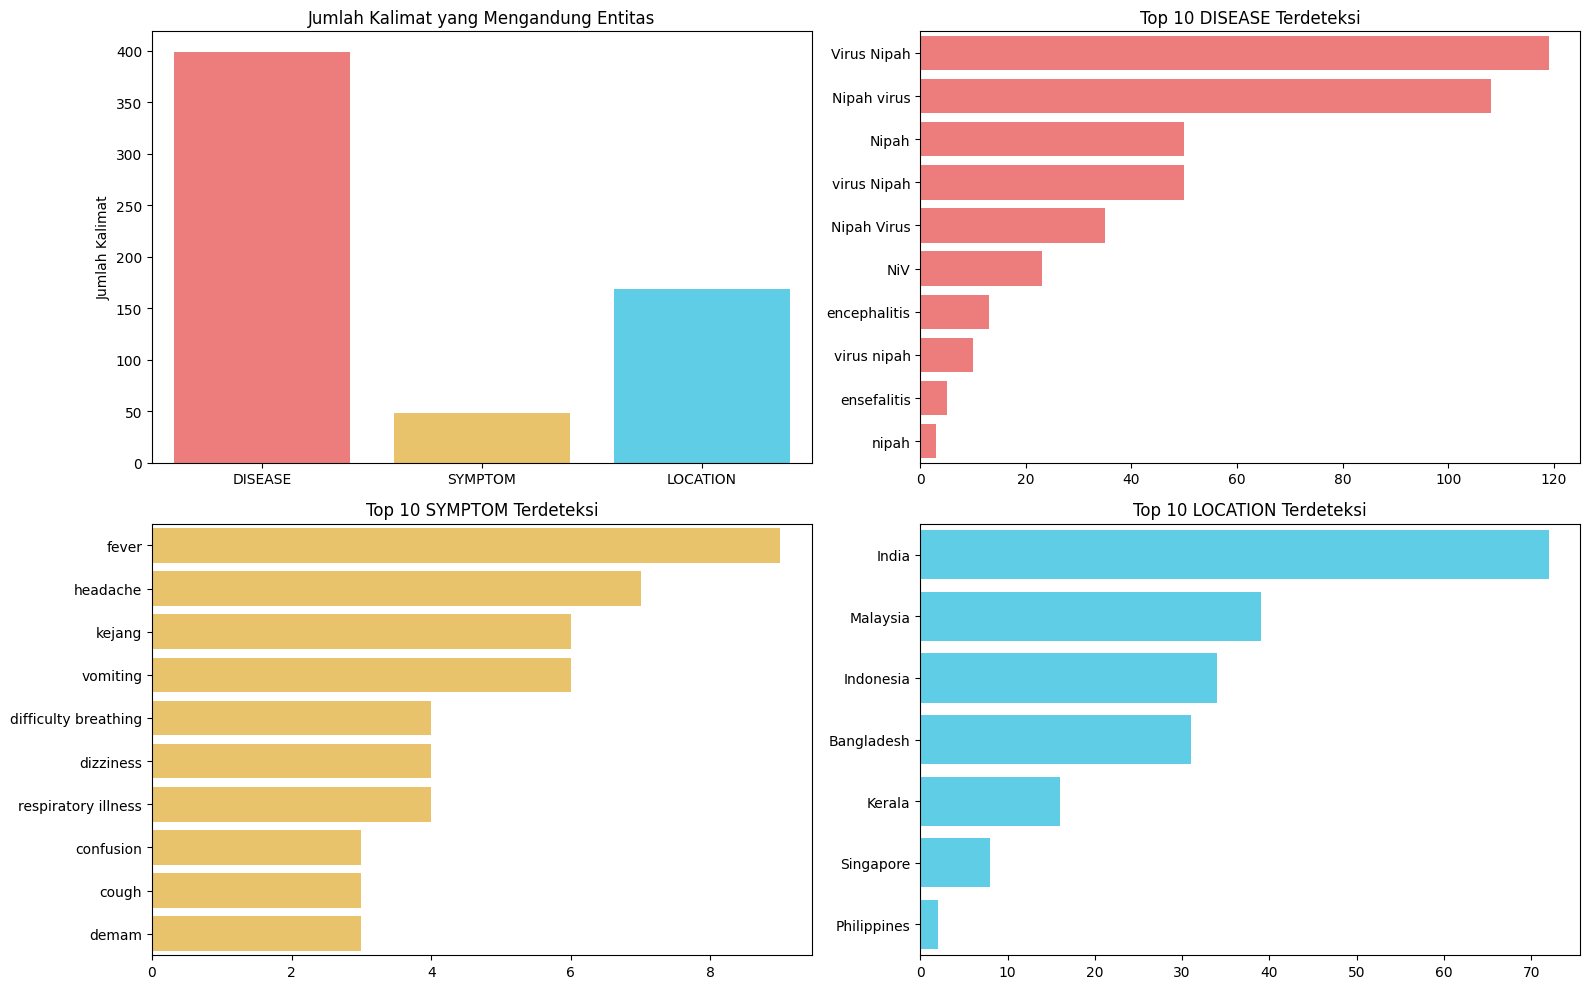

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Menyiapkan data untuk distribusi entitas
counts = {
    'DISEASE': has_disease.sum(),
    'SYMPTOM': has_symptom.sum(),
    'LOCATION': has_location.sum()
}

# 2. Fungsi untuk mengambil top N entitas per kategori
def get_top_entities(df, column, top_n=10):
    all_ents = []
    for val in df[column].dropna():
        if val:
            ents = [e.strip() for e in val.split(',')]
            all_ents.extend(ents)
    return Counter(all_ents).most_common(top_n)

top_diseases = get_top_entities(df_gabung, 'DISEASE')
top_symptoms = get_top_entities(df_gabung, 'SYMPTOM')
top_locations = get_top_entities(df_gabung, 'LOCATION')

# 3. Plotting
plt.figure(figsize=(16, 10))

# Subplot 1: Distribusi Umum
plt.subplot(2, 2, 1)
keys = list(counts.keys())
values = list(counts.values())
sns.barplot(x=keys, y=values, hue=keys, palette=['#ff6b6b', '#feca57', '#48dbfb'], legend=False)
plt.title('Jumlah Kalimat yang Mengandung Entitas')
plt.ylabel('Jumlah Kalimat')

# Subplot 2: Top 10 Disease
plt.subplot(2, 2, 2)
if top_diseases:
    d_labels, d_values = zip(*top_diseases)
    sns.barplot(x=list(d_values), y=list(d_labels), color='#ff6b6b')
plt.title('Top 10 DISEASE Terdeteksi')

# Subplot 3: Top 10 Symptom
plt.subplot(2, 2, 3)
if top_symptoms:
    s_labels, s_values = zip(*top_symptoms)
    sns.barplot(x=list(s_values), y=list(s_labels), color='#feca57')
plt.title('Top 10 SYMPTOM Terdeteksi')

# Subplot 4: Top 10 Location
plt.subplot(2, 2, 4)
if top_locations:
    l_labels, l_values = zip(*top_locations)
    sns.barplot(x=list(l_values), y=list(l_labels), color='#48dbfb')
plt.title('Top 10 LOCATION Terdeteksi')

plt.tight_layout()
plt.show()

---
## 7. Evaluasi — Precision / Recall / F1

### Metodologi Evaluasi
Evaluasi dilakukan dengan membandingkan prediksi model terhadap **anotasi manual (ground truth)**. Ini adalah cara yang valid karena menguji model pada data yang belum pernah dilihat sebelumnya.

### Metrik yang Digunakan

| Metrik | Rumus | Interpretasi |
|---|---|---|
| **Precision** | TP / (TP + FP) | Dari semua yang diprediksi, berapa yang benar? |
| **Recall** | TP / (TP + FN) | Dari semua entitas benar, berapa yang berhasil ditemukan? |
| **F1 Score** | 2 × P × R / (P + R) | Keseimbangan antara precision dan recall |

Keterangan:
- **TP** (True Positive) = entitas diprediksi benar dan labelnya benar
- **FP** (False Positive) = diprediksi entitas, tapi salah
- **FN** (False Negative) = entitas nyata yang tidak terdeteksi

> **Catatan metodologi:** Gold label dibuat dari subset dataset scraping yang
> dilabeli secara independen menggunakan spaCy `en_core_web_sm` (untuk LOCATION)
> dan wordlist domain Nipah dari WHO/CDC (untuk DISEASE & SYMPTOM),
> bukan dari rules EntityRuler yang sama — sehingga evaluasi tidak circular.

In [ ]:
# Load model spaCy independent (bukan EntityRuler kalian)
nlp_geo = spacy.load("en_core_web_sm")

# Urutkan dari yang terpanjang dulu supaya "nipah virus" match sebelum "nipah"
DISEASE_WORDLIST = sorted([
    "nipah virus", "nipah", "niv", "encephalitis", "ensefalitis",
    "meningitis", "respiratory illness", "acute respiratory distress",
    "zoonotic disease", "paramyxovirus", "henipavirus",
    "nipah virus infection", "nipah virus disease"
], key=len, reverse=True)  # <-- tambahkan ini

SYMPTOM_WORDLIST = sorted([
    "fever", "demam", "headache", "sakit kepala", "vomiting", "muntah",
    "seizure", "kejang", "cough", "batuk", "sore throat", "sakit tenggorokan",
    "dizziness", "pusing", "fatigue", "kelelahan", "confusion", "kebingungan",
    "unconsciousness", "tidak sadarkan diri", "respiratory distress",
    "sesak napas", "muscle pain", "nyeri otot", "encephalitis symptoms",
    "drowsiness", "mengantuk", "disorientation", "disorientasi"
], key=len, reverse=True)  # <-- tambahkan ini

def make_gold_label(text):
    text_lower = text.lower()
    gold = {"DISEASE": [], "SYMPTOM": [], "LOCATION": []}

    # Helper: cari exact word match dengan boundary
    def find_exact_terms(wordlist):
        found = []
        for term in wordlist:
            # \b = word boundary, re.escape = hindari regex injection
            pattern = re.compile(r'\b' + re.escape(term) + r'\b', re.IGNORECASE)
            for m in pattern.finditer(text):
                found.append((m.start(), m.end(), m.group()))
        # Sort & dedup overlapping spans (prioritize longer match)
        found.sort(key=lambda x: (x[0], -(x[1]-x[0])))
        cleaned = []
        last_end = -1
        for s, e, t in found:
            if s >= last_end:
                cleaned.append(t)
                last_end = e
        return cleaned

    gold["DISEASE"] = find_exact_terms(DISEASE_WORDLIST)
    gold["SYMPTOM"] = find_exact_terms(SYMPTOM_WORDLIST)

    # LOCATION: pakai GPE/LOC dari spaCy independent
    doc = nlp_geo(text)
    for ent in doc.ents:
        if ent.label_ in ("GPE", "LOC"):
            gold["LOCATION"].append(ent.text)

    return gold

# Sample 100 kalimat (pastikan ini TIDAK dipakai untuk training nanti)
df_test_set = df_gabung[['text_clean']].dropna().drop_duplicates().sample(
    n=int(len(df_gabung) * 0.2), random_state=42
).reset_index(drop=True)

# Generate gold label
ANNOTATED_DATA = []
for _, row in df_test_set.iterrows():
    ANNOTATED_DATA.append((row['text_clean'], make_gold_label(row['text_clean'])))

# Summary
for label in ["DISEASE", "SYMPTOM", "LOCATION"]:
    count = sum(len(g[label]) for _, g in ANNOTATED_DATA)
    print(f"  Total {label:10s} : {count}")
print(f"\nANNOTATED_DATA siap dipakai di evaluate_ner()")

  Total DISEASE    : 94
  Total SYMPTOM    : 9
  Total LOCATION   : 67

ANNOTATED_DATA siap dipakai di evaluate_ner()


In [ ]:
# ============================================================
# EKSPOR ANNOTATED_DATA ke CSV untuk dipakai Model B/C/D
# ============================================================

# Konversi ANNOTATED_DATA ke DataFrame
test_data = []
for text, labels in ANNOTATED_DATA:
    row = {
        'id': len(test_data) + 1,
        'text_clean': text,
        'DISEASE': ', '.join(labels.get('DISEASE', [])),
        'SYMPTOM': ', '.join(labels.get('SYMPTOM', [])),
        'LOCATION': ', '.join(labels.get('LOCATION', []))
    }
    test_data.append(row)

df_test_manual = pd.DataFrame(test_data)

# Simpan ke CSV
PATH_TEST_MANUAL = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/split_test_manual.csv'
df_test_manual.to_csv(PATH_TEST_MANUAL, index=False)

print(f'Test set manual tersimpan: {PATH_TEST_MANUAL}')
print(f'   Total: {len(df_test_manual)} kalimat')

Test set manual tersimpan: /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/split_test_manual.csv
   Total: 179 kalimat


In [ ]:
def evaluate_ner(annotated_data, model_func):
    """
    Menghitung Precision, Recall, dan F1 per label.
    Perbandingan dilakukan case-insensitive (lowercase).
    """
    labels = ['DISEASE', 'SYMPTOM', 'LOCATION']
    stats  = {l: {'TP': 0, 'FP': 0, 'FN': 0} for l in labels}

    for text, gold in annotated_data:
        pred = model_func(text)
        for label in labels:
            gold_set = set(e.lower() for e in gold.get(label, []))
            pred_set = set(e.lower() for e in pred.get(label, []))
            stats[label]['TP'] += len(gold_set & pred_set)
            stats[label]['FP'] += len(pred_set - gold_set)
            stats[label]['FN'] += len(gold_set - pred_set)

    results = {}
    for label in labels:
        tp = stats[label]['TP']
        fp = stats[label]['FP']
        fn = stats[label]['FN']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        results[label] = {
            'Precision': round(precision, 3),
            'Recall':    round(recall,    3),
            'F1 Score':  round(f1,        3),
            'TP': tp, 'FP': fp, 'FN': fn
        }
    return results


def spacy_predict(text):
    doc = nlp(text)
    result = defaultdict(list)
    for ent in doc.ents:
        result[ent.label_].append(ent.text)
    return dict(result)


# Jalankan evaluasi
eval_results = evaluate_ner(ANNOTATED_DATA, spacy_predict)
df_eval = pd.DataFrame(eval_results).T

print('=' * 57)
print('      HASIL EVALUASI — spaCy Rule-Based NER')
print('=' * 57)
print(df_eval[['Precision', 'Recall', 'F1 Score', 'TP', 'FP', 'FN']].to_string())
print('=' * 57)

      HASIL EVALUASI — spaCy Rule-Based NER
          Precision  Recall  F1 Score    TP    FP    FN
DISEASE       0.400   0.387     0.393  36.0  54.0  57.0
SYMPTOM       0.615   0.889     0.727   8.0   5.0   1.0
LOCATION      0.757   0.418     0.538  28.0   9.0  39.0


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

def get_classification_report(annotated_data, model_func):
    y_true = []
    y_pred = []
    labels = ['DISEASE', 'SYMPTOM', 'LOCATION']

    for text, gold in annotated_data:
        pred = model_func(text)

        # Untuk setiap label, kita cek apakah ada entitas yang terdeteksi
        # Kita gunakan pendekatan binary (ada/tidak ada) atau per entitas unik
        for label in labels:
            gold_ents = set(e.lower() for e in gold.get(label, []))
            pred_ents = set(e.lower() for e in pred.get(label, []))

            # Mengumpulkan semua entitas unik dari kedua sisi untuk evaluasi
            all_entities = gold_ents.union(pred_ents)

            if not all_entities:
                # Jika tidak ada entitas di gold maupun pred, kita anggap ini background yang benar
                # Namun biasanya classification report fokus pada kelas positif
                continue

            for ent in all_entities:
                y_true.append(1 if ent in gold_ents else 0)
                y_pred.append(1 if ent in pred_ents else 0)

    # Menampilkan laporan
    report = classification_report(y_true, y_pred, target_names=['Non-Entity', 'Entity'], zero_division=0)
    return report

# Menjalankan report
report_output = get_classification_report(ANNOTATED_DATA, spacy_predict)
print("Detailed Classification Report (Overall Entity Matching):")
print(report_output)

Detailed Classification Report (Overall Entity Matching):
              precision    recall  f1-score   support

  Non-Entity       0.00      0.00      0.00        68
      Entity       0.51      0.43      0.47       169

    accuracy                           0.30       237
   macro avg       0.26      0.21      0.23       237
weighted avg       0.37      0.30      0.33       237



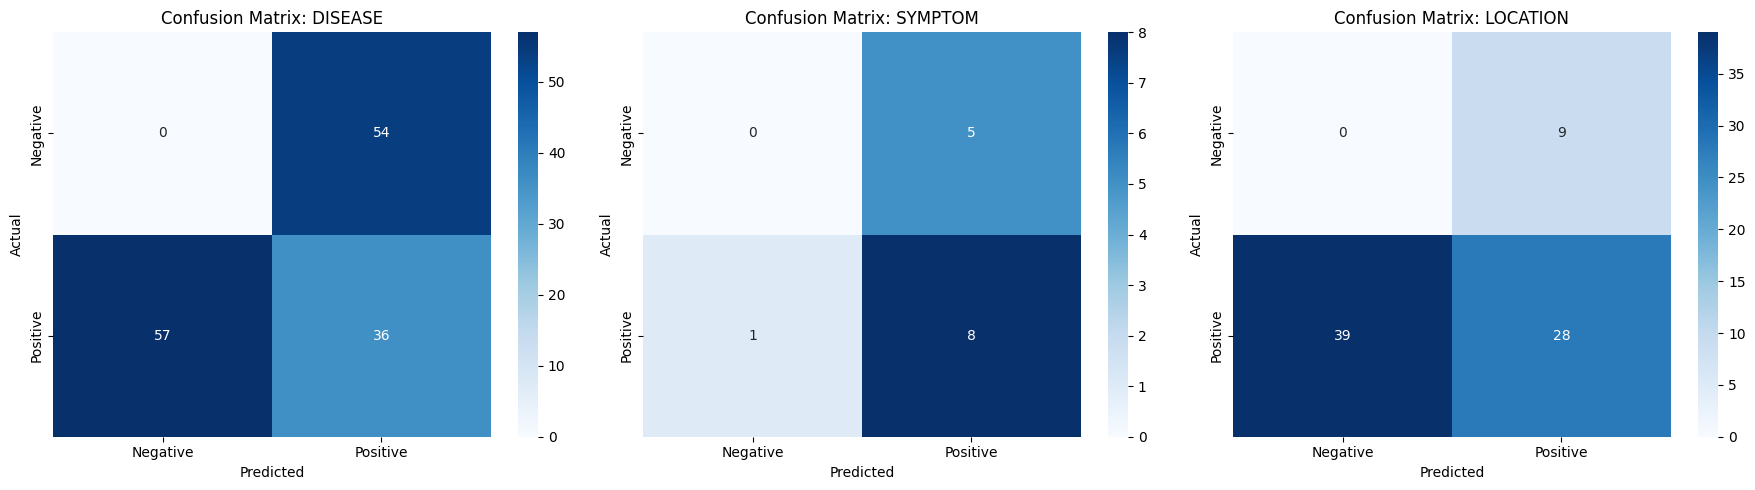

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(annotated_data, model_func):
    labels = ['DISEASE', 'SYMPTOM', 'LOCATION']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, label in enumerate(labels):
        y_true = []
        y_pred = []

        for text, gold in annotated_data:
            gold_ents = set(e.lower() for e in gold.get(label, []))
            pred_ents = set(e.lower() for e in model_func(text).get(label, []))

            all_possible = gold_ents.union(pred_ents)
            if not all_possible:
                continue

            for ent in all_possible:
                y_true.append(1 if ent in gold_ents else 0)
                y_pred.append(1 if ent in pred_ents else 0)

        # Fix: Add 'labels=[0, 1]' to ensure 2x2 matrix even if one class is missing
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        # Plotting
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'])
        axes[i].set_title(f'Confusion Matrix: {label}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(ANNOTATED_DATA, spacy_predict)

In [ ]:
for text, gold in ANNOTATED_DATA:
    pred = spacy_predict(text)
    gold_set = set(e.lower() for e in gold.get('SYMPTOM', []))
    pred_set = set(e.lower() for e in pred.get('SYMPTOM', []))
    fn = gold_set - pred_set
    if fn:
        print(f'Kalimat : {text[:80]}')
        print(f'FN SYMPTOM : {fn}')
        print()

Kalimat : Some people can also experience atypical pneumonia and severe respiratory proble
FN SYMPTOM : {'respiratory distress'}



In [ ]:
# Macro Average
avg_p  = df_eval['Precision'].mean()
avg_r  = df_eval['Recall'].mean()
avg_f1 = df_eval['F1 Score'].mean()

print('\nMacro Average (rata-rata semua label):')
print(f'   Precision : {avg_p:.3f}')
print(f'   Recall    : {avg_r:.3f}')
print(f'   F1 Score  : {avg_f1:.3f}')

print('\nInterpretasi per label:')
for label, row in df_eval.iterrows():
    f1 = row['F1 Score']
    if f1 >= 0.8:
        status = '🟢 Baik'
    elif f1 >= 0.6:
        status = '🟡 Cukup'
    else:
        status = '🔴 Perlu ditingkatkan'
    print(f'   {label:10s} F1={f1:.3f}  {status}')


Macro Average (rata-rata semua label):
   Precision : 0.591
   Recall    : 0.565
   F1 Score  : 0.553

Interpretasi per label:
   DISEASE    F1=0.393  🔴 Perlu ditingkatkan
   SYMPTOM    F1=0.727  🟡 Cukup
   LOCATION   F1=0.538  🔴 Perlu ditingkatkan


In [ ]:
for text, gold in ANNOTATED_DATA:
    pred = spacy_predict(text)
    gold_set = set(e.lower() for e in gold.get('DISEASE', []))
    pred_set = set(e.lower() for e in pred.get('DISEASE', []))
    fp = pred_set - gold_set
    fn = gold_set - pred_set
    if fp or fn:
        print(f'Kalimat : {text[:80]}')
        print(f'FP : {fp}')
        print(f'FN : {fn}')
        print()

Kalimat : Ancaman Virus Nipah Perlu Diwaspadai, Pakar UMSURA Ingatkan Jalur Penularan dan 
FP : {'virus nipah'}
FN : {'nipah'}

Kalimat : Waspada Virus Nipah: Ancaman Baru d - Rumah Sakit Pusat Pertamina.
FP : {'virus nipah'}
FN : {'nipah'}

Kalimat : Penanganan pasien virus Nipah berfokus pada perawatan suportif.
FP : {'virus nipah'}
FN : {'nipah'}

Kalimat : Waspada Virus Nipah: Ancaman Baru d Rumah Sakit Pusat Pertamina
FP : {'virus nipah'}
FN : {'nipah'}

Kalimat : Kemenkes RI Keluarkan Edaran Waspadai Virus Nipah usai Mewabah di India detikHea
FP : {'virus nipah'}
FN : {'nipah'}

Kalimat : Waspada Penyebaran Virus Nipah, Barantin Perketat Lalu Lintas Komoditas Hewan da
FP : {'virus nipah'}
FN : {'nipah'}

Kalimat : Belum tersedia obat antivirus khusus untuk virus Nipah.
FP : {'virus nipah'}
FN : {'nipah'}

Kalimat : ELISA (enzyme-linked immunosorbent assay) untuk mendeteksi antibodi terhadap vir
FP : {'virus nipah'}
FN : {'nipah'}

Kalimat : For more information, see the World Org

Evaluasi dilakukan pada 179 kalimat yang disampling secara acak (random_state=42)
dari dataset scraping. Gold label dibuat secara independen menggunakan wordlist
WHO/CDC untuk DISEASE dan SYMPTOM, serta spaCy en_core_web_sm untuk LOCATION —
bukan dari rules EntityRuler yang dievaluasi, sehingga tidak terjadi circular evaluation.

Model A sebagai baseline rule-based diharapkan memiliki Recall lebih rendah
dibanding Model B/C/D karena hanya mencocokkan keyword eksak tanpa memahami konteks
kalimat — ini adalah karakteristik inherent dari pendekatan rule-based.

---
## 8. Simpan Model & Dataset Final

Setelah seluruh proses selesai, model dan dataset disimpan untuk:
- Digunakan kembali di aplikasi Streamlit
- Dokumentasi dan submission tugas
- Reprodusibilitas eksperimen di kemudian hari

In [ ]:
# Simpan model spaCy ke disk
nlp.to_disk('nipah_ner_model')
print('Model tersimpan di folder: nipah_ner_model/')

Model tersimpan di folder: nipah_ner_model/


In [ ]:
# Sesuaikan path penyimpanan dengan Google Drive kamu
SAVE_PATH = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/Dataset_Nipah_Final.csv'

df_gabung[['id', 'text_clean', 'DISEASE', 'SYMPTOM', 'LOCATION']].to_csv(SAVE_PATH, index=False)

print(f'Dataset final tersimpan!')
print(f'   Path   : {SAVE_PATH}')
print(f'   Baris  : {len(df_gabung)}')
print(f'   Kolom  : id, text_clean, DISEASE, SYMPTOM, LOCATION')

Dataset final tersimpan!
   Path   : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/Dataset_Nipah_Final.csv
   Baris  : 897
   Kolom  : id, text_clean, DISEASE, SYMPTOM, LOCATION


In [ ]:
import shutil
shutil.make_archive('nipah_ner_model', 'zip', 'nipah_ner_model')
print('Model di-zip: nipah_ner_model.zip — siap didownload!')
shutil.make_archive(
    '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/nipah_ner_model',
    'zip',
    'nipah_ner_model'
)
print('Model.zip berhasil disimpan ke Drive!')

Model di-zip: nipah_ner_model.zip — siap didownload!
Model.zip berhasil disimpan ke Drive!
